# Create VGGFace2 Landmarks With FAN

This notebook uses the FAN wrapper from `/home/jie/Documents/NextFace_custom/landmarks/fan.py` to create DECA-style landmark `.npy` files for raw VGGFace2 images.

Input image layout:

```text
/home/jie/Downloads/vggface2_train/train/<identity>/<image>.jpg
```

Output landmark layout:

```text
/home/jie/Downloads/vggface2_train/train_annotated_fan/<identity>/<image>.npy
```

That output folder can later be used as DECA's `kptfolder`. Each `.npy` contains FAN 68-point 2D landmarks with shape `[68, 2]` in original image pixel coordinates.

In [1]:
from pathlib import Path
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from skimage.io import imread
from tqdm.auto import tqdm

PROJECT_ROOT = Path('/home/jie/Documents/NextFace_custom')
DECA_ROOT = PROJECT_ROOT / 'ext' / 'deca'
sys.path.insert(0, str(PROJECT_ROOT))

IMAGE_ROOT = Path('/home/jie/Downloads/vggface2_train/train')
FIRST_PASS_KPT_ROOT = Path('/home/jie/Downloads/vggface2_train/train_annotated_fan')
KPT_ROOT = FIRST_PASS_KPT_ROOT

CLEAN_LIST_PATH = Path('/home/jie/Downloads/vggface2_train/vggface2_train_fan_stability_clean_list.npy')
CLEAN_METADATA_PATH = Path('/home/jie/Downloads/vggface2_train/vggface2_train_fan_stability_clean_metadata.npz')
ACCEPTED_NAMES_PATH = Path('/home/jie/Downloads/vggface2_train/vggface2_train_fan_stability_clean_names.txt')

print('PROJECT_ROOT =', PROJECT_ROOT)
print('IMAGE_ROOT =', IMAGE_ROOT, IMAGE_ROOT.exists())
print('FIRST_PASS_KPT_ROOT =', FIRST_PASS_KPT_ROOT, FIRST_PASS_KPT_ROOT.exists())
print('CLEAN_LIST_PATH =', CLEAN_LIST_PATH)


PROJECT_ROOT = /home/jie/Documents/NextFace_custom
IMAGE_ROOT = /home/jie/Downloads/vggface2_train/train True
FIRST_PASS_KPT_ROOT = /home/jie/Downloads/vggface2_train/train_annotated_fan True
CLEAN_LIST_PATH = /home/jie/Downloads/vggface2_train/vggface2_train_fan_stability_clean_list.npy


/home/jie/Documents/NextFace_custom/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load FAN

`LandmarksDetectorFAN` takes a mask of landmark indices. For DECA/VGGFace2, use all 68 FAN landmarks, so the mask is `torch.arange(68)`.

The first run may take longer because the `face_alignment` package may initialize model weights.

In [2]:
from landmarks.fan import LandmarksDetectorFAN

device = 'cuda' if torch.cuda.is_available() else 'cpu'
mask = torch.arange(68, dtype=torch.long)
fan = LandmarksDetectorFAN(mask=mask, device=device)

print('device =', device)

device = cuda


## Collect Images

The output path is computed by preserving the path relative to `IMAGE_ROOT` and changing `.jpg` to `.npy`.

In [3]:
image_paths = sorted(
    list(IMAGE_ROOT.glob('*/*.jpg'))
    + list(IMAGE_ROOT.glob('*/*.jpeg'))
    + list(IMAGE_ROOT.glob('*/*.png'))
)
image_path_by_name = {
    image_path.relative_to(IMAGE_ROOT).with_suffix('').as_posix(): image_path
    for image_path in image_paths
}

print('num images:', len(image_paths))
print('first image:', image_paths[0] if image_paths else None)


def image_name_for_path(image_path):
    return Path(image_path).relative_to(IMAGE_ROOT).with_suffix('').as_posix()


def kpt_path_for_image(image_path):
    rel = Path(image_path).relative_to(IMAGE_ROOT)
    return (FIRST_PASS_KPT_ROOT / rel).with_suffix('.npy')


if image_paths:
    print('first cached first-pass landmarks:', kpt_path_for_image(image_paths[0]))


num images: 3141890
first image: /home/jie/Downloads/vggface2_train/train/n000002/0001_01.jpg
first cached first-pass landmarks: /home/jie/Downloads/vggface2_train/train_annotated_fan/n000002/0001_01.npy


## Optional Paper-Style Stability Cleaning

The DECA paper describes a data-cleaning step that runs FAN twice with two related bounding boxes. It shifts the original bounding box by 5% to the bottom-right, expands both boxes, detects landmarks from both, shifts the second landmark set back by the same offset, and rejects images whose normalized landmark disagreement is too large.

This notebook now reuses the cached full-image FAN landmarks in `FIRST_PASS_KPT_ROOT` as the first pass. Those cached landmarks define the proxy original bbox, so the expensive batch loop only runs the two bbox-conditioned FAN passes: expanded original bbox and expanded shifted bbox.


In [4]:
def read_image_rgb_float(image_path):
    image = imread(image_path)
    if image.ndim == 2:
        image = np.repeat(image[..., None], 3, axis=2)
    if image.shape[2] == 4:
        image = image[..., :3]
    return image.astype(np.float32) / 255.0


def load_first_pass_landmarks(image_path):
    kpt_path = kpt_path_for_image(image_path)
    if not kpt_path.is_file():
        raise FileNotFoundError(f'missing cached first-pass FAN landmarks: {kpt_path}')

    landmarks = np.load(kpt_path).astype(np.float32)
    if landmarks.ndim != 2 or landmarks.shape[1] < 2:
        raise ValueError(f'unexpected landmark shape in {kpt_path}: {landmarks.shape}')
    return landmarks[:, :2]


def landmarks_to_bbox(landmarks):
    left = float(np.min(landmarks[:, 0]))
    right = float(np.max(landmarks[:, 0]))
    top = float(np.min(landmarks[:, 1]))
    bottom = float(np.max(landmarks[:, 1]))
    return np.array([left, top, right, bottom], dtype=np.float32)


def bbox_size(bbox):
    x1, y1, x2, y2 = np.asarray(bbox, dtype=np.float32)
    bw = max(float(x2 - x1), 1.0)
    bh = max(float(y2 - y1), 1.0)
    return bw, bh


def clip_bbox(bbox, image_shape):
    h, w = image_shape[:2]
    bbox = np.asarray(bbox, dtype=np.float32).copy()
    bbox[[0, 2]] = np.clip(bbox[[0, 2]], 0, w - 1)
    bbox[[1, 3]] = np.clip(bbox[[1, 3]], 0, h - 1)
    return bbox


def expand_bbox_for_cleaning(bbox, image_shape, top=0.10, left=0.20, right=0.20, bottom=0.20):
    x1, y1, x2, y2 = np.asarray(bbox, dtype=np.float32)
    bw, bh = bbox_size(bbox)
    expanded = np.array([
        x1 - left * bw,
        y1 - top * bh,
        x2 + right * bw,
        y2 + bottom * bh,
    ], dtype=np.float32)
    return clip_bbox(expanded, image_shape)


def shift_bbox_bottom_right(bbox, epsilon):
    epsilon = np.asarray(epsilon, dtype=np.float32)
    return np.asarray(bbox, dtype=np.float32) + np.array(
        [epsilon[0], epsilon[1], epsilon[0], epsilon[1]], dtype=np.float32
    )


def fan_landmarks_from_bbox(image_float, bbox, image_path=None, pass_name=None):
    image_uint8 = np.clip(image_float * 255.0, 0, 255).astype(np.uint8)
    # face_alignment expects ordinary Python scalars here; NumPy scalars can fail on older Torch.
    faces = [[float(v) for v in np.asarray(bbox, dtype=np.float32).reshape(4)]]
    with torch.no_grad():
        arr = fan.landmarksDetector.get_landmarks_from_image(image_uint8, detected_faces=faces)

    image_label = 'unknown image'
    if image_path is not None:
        try:
            image_label = Path(image_path).relative_to(IMAGE_ROOT).as_posix()
        except ValueError:
            image_label = str(image_path)
    pass_label = f' [{pass_name}]' if pass_name is not None else ''

    if arr is None or len(arr) == 0:
        raise RuntimeError(f'No landmarks found with provided bbox for {image_label}{pass_label}')
    return np.asarray(arr[0][:, :2], dtype=np.float32)


def paper_style_stability_score(k1, k2, epsilon, bbox):
    bw, bh = bbox_size(bbox)
    epsilon = np.asarray(epsilon, dtype=np.float32)
    D = np.diag(np.array([1.0 / bw, 1.0 / bh], dtype=np.float32))

    k2_aligned = k2 - epsilon[None, :]
    delta = k2_aligned - k1
    normalized_delta = delta @ D
    per_landmark_distance = np.linalg.norm(normalized_delta, axis=1)
    score = float(np.max(per_landmark_distance))

    return score, k2_aligned, delta, normalized_delta, per_landmark_distance, D


def paper_style_stability_details_from_cached_first_pass(image_path, threshold=0.10):
    image = read_image_rgb_float(image_path)
    initial_kpt = load_first_pass_landmarks(image_path)

    # Raw VGGFace2 does not give the paper's original bbox, so cached full-image FAN is the proxy.
    original_bbox = landmarks_to_bbox(initial_kpt)
    bw, bh = bbox_size(original_bbox)
    epsilon = np.array([0.05 * bw, 0.05 * bh], dtype=np.float32)

    shifted_bbox = shift_bbox_bottom_right(original_bbox, epsilon)
    expanded_original_bbox = expand_bbox_for_cleaning(original_bbox, image.shape)
    expanded_shifted_bbox = expand_bbox_for_cleaning(shifted_bbox, image.shape)

    k1 = fan_landmarks_from_bbox(
        image,
        expanded_original_bbox,
        image_path=image_path,
        pass_name='k1 expanded original bbox',
    )
    k2 = fan_landmarks_from_bbox(
        image,
        expanded_shifted_bbox,
        image_path=image_path,
        pass_name='k2 expanded shifted bbox',
    )
    score, k2_aligned, delta, normalized_delta, per_landmark_distance, D = paper_style_stability_score(
        k1, k2, epsilon, original_bbox
    )

    return {
        'image': image,
        'initial_kpt': initial_kpt,
        'original_bbox': original_bbox,
        'bbox_width_height': np.array([bw, bh], dtype=np.float32),
        'epsilon': epsilon,
        'shifted_bbox': shifted_bbox,
        'expanded_original_bbox': expanded_original_bbox,
        'expanded_shifted_bbox': expanded_shifted_bbox,
        'k1': k1,
        'k2': k2,
        'k2_aligned': k2_aligned,
        'delta': delta,
        'D': D,
        'normalized_delta': normalized_delta,
        'per_landmark_distance': per_landmark_distance,
        'score': score,
        'worst_landmark_index': int(np.argmax(per_landmark_distance)),
        'threshold': threshold,
        'accepted': score < threshold,
    }


paper_style_stability_details = paper_style_stability_details_from_cached_first_pass


def detect_landmarks_clean(image_path, threshold=0.10):
    details = paper_style_stability_details_from_cached_first_pass(image_path, threshold=threshold)
    if not details['accepted']:
        raise RuntimeError(f"unstable FAN landmarks: score={details['score']:.4f} >= threshold={threshold}")

    return (
        details['image'],
        details['k1'].astype(np.float32),
        details['score'],
        details['original_bbox'],
    )


## Process Many Images

This loop processes every cached full-image FAN landmark file in `FIRST_PASS_KPT_ROOT`, reruns only the two bbox-conditioned FAN passes, and writes a flat clean list of accepted relative image names. With resume enabled, rerunning the cell skips names already present in the checkpoint metadata.


In [6]:
LIMIT = None  # keep None to process all cached first-pass landmarks
STABILITY_THRESHOLD = 0.10
RESUME = True
RETRY_FAILURES = True
CHECKPOINT_EVERY = 1000


def empty_bbox_array():
    return np.empty((0, 4), dtype=np.float32)


def load_existing_results():
    accepted_records = []
    rejection_records = []
    failure_records = []

    if CLEAN_METADATA_PATH.is_file():
        metadata = np.load(CLEAN_METADATA_PATH, allow_pickle=False)
        accepted_names = metadata.get('accepted_names', np.asarray([], dtype=str)).astype(str)
        accepted_scores = metadata.get('accepted_scores', np.full(len(accepted_names), np.nan, dtype=np.float32))
        accepted_worst = metadata.get('accepted_worst_landmarks', np.full(len(accepted_names), -1, dtype=np.int64))
        accepted_bboxes = metadata.get('accepted_bboxes', empty_bbox_array())

        for i, name in enumerate(accepted_names):
            bbox = accepted_bboxes[i] if i < len(accepted_bboxes) else np.full(4, np.nan, dtype=np.float32)
            accepted_records.append({
                'name': str(name),
                'score': float(accepted_scores[i]) if i < len(accepted_scores) else np.nan,
                'worst_landmark_index': int(accepted_worst[i]) if i < len(accepted_worst) else -1,
                'bbox': np.asarray(bbox, dtype=np.float32),
            })

        rejected_names = metadata.get('rejected_names', np.asarray([], dtype=str)).astype(str)
        rejected_scores = metadata.get('rejected_scores', np.full(len(rejected_names), np.nan, dtype=np.float32))
        rejected_thresholds = metadata.get('rejected_thresholds', np.full(len(rejected_names), STABILITY_THRESHOLD, dtype=np.float32))
        rejected_worst = metadata.get('rejected_worst_landmarks', np.full(len(rejected_names), -1, dtype=np.int64))
        for i, name in enumerate(rejected_names):
            rejection_records.append((
                str(name),
                float(rejected_scores[i]) if i < len(rejected_scores) else np.nan,
                float(rejected_thresholds[i]) if i < len(rejected_thresholds) else STABILITY_THRESHOLD,
                int(rejected_worst[i]) if i < len(rejected_worst) else -1,
            ))

        failure_names = metadata.get('failure_names', np.asarray([], dtype=str)).astype(str)
        failure_errors = metadata.get('failure_errors', np.full(len(failure_names), '', dtype=str)).astype(str)
        for i, name in enumerate(failure_names):
            failure_records.append((
                str(name),
                str(failure_errors[i]) if i < len(failure_errors) else '',
            ))
    elif CLEAN_LIST_PATH.is_file():
        existing_names = np.load(CLEAN_LIST_PATH, allow_pickle=False).astype(str).reshape(-1)
        for name in existing_names:
            accepted_records.append({
                'name': str(name),
                'score': np.nan,
                'worst_landmark_index': -1,
                'bbox': np.full(4, np.nan, dtype=np.float32),
            })

    return accepted_records, rejection_records, failure_records


def save_checkpoint(accepted_records, rejection_records, failure_records):
    CLEAN_LIST_PATH.parent.mkdir(parents=True, exist_ok=True)

    accepted_names = np.asarray([record['name'] for record in accepted_records], dtype=str)
    accepted_scores = np.asarray([record['score'] for record in accepted_records], dtype=np.float32)
    accepted_worst_landmarks = np.asarray(
        [record['worst_landmark_index'] for record in accepted_records],
        dtype=np.int64,
    )
    accepted_bboxes = (
        np.asarray([record['bbox'] for record in accepted_records], dtype=np.float32)
        if accepted_records
        else empty_bbox_array()
    )

    np.save(CLEAN_LIST_PATH, accepted_names)
    ACCEPTED_NAMES_PATH.write_text('\n'.join(accepted_names.tolist()) + ('\n' if len(accepted_names) else ''))

    np.savez_compressed(
        CLEAN_METADATA_PATH,
        accepted_names=accepted_names,
        accepted_scores=accepted_scores,
        accepted_worst_landmarks=accepted_worst_landmarks,
        accepted_bboxes=accepted_bboxes,
        rejected_names=np.asarray([row[0] for row in rejection_records], dtype=str),
        rejected_scores=np.asarray([row[1] for row in rejection_records], dtype=np.float32),
        rejected_thresholds=np.asarray([row[2] for row in rejection_records], dtype=np.float32),
        rejected_worst_landmarks=np.asarray([row[3] for row in rejection_records], dtype=np.int64),
        failure_names=np.asarray([row[0] for row in failure_records], dtype=str),
        failure_errors=np.asarray([row[1] for row in failure_records], dtype=str),
    )


first_pass_paths = sorted(FIRST_PASS_KPT_ROOT.glob('*/*.npy'))
candidate_names = [
    kpt_path.relative_to(FIRST_PASS_KPT_ROOT).with_suffix('').as_posix()
    for kpt_path in first_pass_paths
]
candidate_names = [name for name in candidate_names if name in image_path_by_name]
if LIMIT is not None:
    candidate_names = candidate_names[:LIMIT]

if RESUME:
    accepted, rejections, failures = load_existing_results()
    if RETRY_FAILURES:
        failures = []
else:
    accepted, rejections, failures = [], [], []

processed_names = (
    {record['name'] for record in accepted}
    | {row[0] for row in rejections}
    | {row[0] for row in failures}
)
names_to_process = [name for name in candidate_names if name not in processed_names]
scores = []

print('cached first-pass files:', len(first_pass_paths))
print('candidates with matching images:', len(candidate_names))
print('already processed from checkpoint:', len(processed_names))
print('remaining to process:', len(names_to_process))

for step, name in enumerate(tqdm(names_to_process), start=1):
    image_path = image_path_by_name[name]

    try:
        details = paper_style_stability_details_from_cached_first_pass(
            image_path,
            threshold=STABILITY_THRESHOLD,
        )
        scores.append(details['score'])

        if not details['accepted']:
            rejections.append((
                name,
                details['score'],
                details['threshold'],
                details['worst_landmark_index'],
            ))
        else:
            accepted.append({
                'name': name,
                'score': details['score'],
                'worst_landmark_index': details['worst_landmark_index'],
                'bbox': details['original_bbox'].astype(np.float32),
            })
    except Exception as exc:
        failures.append((name, repr(exc)))

    if CHECKPOINT_EVERY and step % CHECKPOINT_EVERY == 0:
        save_checkpoint(accepted, rejections, failures)

save_checkpoint(accepted, rejections, failures)

print('processed this run:', len(names_to_process))
print('accepted total:', len(accepted))
print('rejected total:', len(rejections))
print('failures total:', len(failures))
print('saved flat clean list shape:', np.load(CLEAN_LIST_PATH, allow_pickle=False).shape)
print('saved clean list:', CLEAN_LIST_PATH)
print('saved metadata:', CLEAN_METADATA_PATH)
print('saved accepted names:', ACCEPTED_NAMES_PATH)
if scores:
    print('this-run score min/mean/max:', float(np.min(scores)), float(np.mean(scores)), float(np.max(scores)))
print('first rejections:', rejections[:5])
failures[:5]


cached first-pass files: 882179
candidates with matching images: 882179
already processed from checkpoint: 882213
remaining to process: 0


0it [00:00, ?it/s]


processed this run: 0
accepted total: 706801
rejected total: 175412
failures total: 0
saved flat clean list shape: (706801,)
saved clean list: /home/jie/Downloads/vggface2_train/vggface2_train_fan_stability_clean_list.npy
saved metadata: /home/jie/Downloads/vggface2_train/vggface2_train_fan_stability_clean_metadata.npz
saved accepted names: /home/jie/Downloads/vggface2_train/vggface2_train_fan_stability_clean_names.txt
first rejections: [('n000002/0007_01', 0.10302549600601196, 0.10000000149011612, 50), ('n000002/0016_01', 0.10752790421247482, 0.10000000149011612, 36), ('n000002/0018_03', 0.10952455550432205, 0.10000000149011612, 62), ('n000002/0026_01', 0.10969685018062592, 0.10000000149011612, 3), ('n000002/0028_01', 0.10174521058797836, 0.10000000149011612, 28)]


[]

## Inspect Saved Outputs

Use these cells to inspect the flat clean list, checkpoint metadata, accepted-name text file, and landmarks for a specific image name.


In [7]:
# Overview of saved clean list (.npy)
print('clean list path:', CLEAN_LIST_PATH)
print('exists:', CLEAN_LIST_PATH.is_file())

if CLEAN_LIST_PATH.is_file():
    clean_names = np.load(CLEAN_LIST_PATH, allow_pickle=False).astype(str).reshape(-1)
    identities = np.asarray([name.split('/')[0] for name in clean_names], dtype=str)
    unique_identities = np.unique(identities) if len(identities) else np.asarray([], dtype=str)

    print('shape:', clean_names.shape)
    print('dtype:', clean_names.dtype)
    print('num accepted names:', len(clean_names))
    print('num unique names:', len(np.unique(clean_names)))
    print('num identities:', len(unique_identities))
    print('last 20 names:')
    for name in clean_names[-20:]:
        print(' ', name)
else:
    clean_names = np.asarray([], dtype=str)


clean list path: /home/jie/Downloads/vggface2_train/vggface2_train_fan_stability_clean_list.npy
exists: True
shape: (706801,)
dtype: <U16
num accepted names: 706801
num unique names: 706801
num identities: 2384
last 20 names:
  n002547/0122_01
  n002547/0123_01
  n002547/0124_01
  n002547/0125_01
  n002547/0126_01
  n002547/0128_01
  n002547/0130_01
  n002547/0131_01
  n002547/0133_01
  n002547/0134_01
  n002547/0135_01
  n002547/0136_01
  n002547/0137_01
  n002547/0138_01
  n002547/0139_01
  n002547/0140_01
  n002547/0141_03
  n002547/0142_01
  n002547/0143_01
  n002547/0144_02


In [31]:
# Overview of saved metadata/checkpoint (.npz)
print('metadata path:', CLEAN_METADATA_PATH)
print('exists:', CLEAN_METADATA_PATH.is_file())

if CLEAN_METADATA_PATH.is_file():
    metadata = np.load(CLEAN_METADATA_PATH, allow_pickle=False)
    print('keys:', list(metadata.files))

    for key in metadata.files:
        arr = metadata[key]
        print(f'\n{key}: shape={arr.shape}, dtype={arr.dtype}')
        if arr.size and key.endswith('scores'):
            print('  min/mean/max:', float(np.nanmin(arr)), float(np.nanmean(arr)), float(np.nanmax(arr)))
        if arr.size:
            print('  first 5:', arr[:5])

    print('\nsummary:')
    print(' accepted:', len(metadata.get('accepted_names', [])))
    print(' rejected:', len(metadata.get('rejected_names', [])))
    print(' failures:', len(metadata.get('failure_names', [])))
else:
    metadata = None

metadata path: /home/jie/Downloads/vggface2_train/vggface2_train_fan_stability_clean_metadata.npz
exists: True
keys: ['accepted_names', 'accepted_scores', 'accepted_worst_landmarks', 'accepted_bboxes', 'rejected_names', 'rejected_scores', 'rejected_thresholds', 'rejected_worst_landmarks', 'failure_names', 'failure_errors']

accepted_names: shape=(392056,), dtype=<U16
  first 5: ['n000002/0001_01' 'n000002/0002_01' 'n000002/0003_01' 'n000002/0004_01'
 'n000002/0005_01']

accepted_scores: shape=(392056,), dtype=float32
  min/mean/max: 0.05339999869465828 0.09205402433872223 0.09999999403953552
  first 5: [0.09295991 0.09376864 0.09527369 0.09746315 0.09975702]

accepted_worst_landmarks: shape=(392056,), dtype=int64
  first 5: [28 58 29 44 60]

accepted_bboxes: shape=(392056, 4), dtype=float32
  first 5: [[106. 232. 389. 476.]
 [ 80. 121. 284. 301.]
 [ 80. 166. 332. 389.]
 [ 60.  82. 200. 211.]
 [ 58. 110. 191. 227.]]

rejected_names: shape=(98751,), dtype=<U15
  first 5: ['n000002/0007_0

In [13]:
# Shared landmark visualization helpers.
LANDMARK_CONNECTIONS_68 = [
    list(range(0, 17)),          # jaw
    list(range(17, 22)),         # right brow
    list(range(22, 27)),         # left brow
    list(range(27, 31)),         # nose bridge
    list(range(31, 36)),         # lower nose
    list(range(36, 42)) + [36],  # right eye closed loop
    list(range(42, 48)) + [42],  # left eye closed loop
    list(range(48, 60)) + [48],  # outer lip closed loop
    list(range(60, 68)) + [60],  # inner lip closed loop
]


def load_image_and_cached_landmarks(name):
    image_path = IMAGE_ROOT / f'{name}.jpg'
    kpt_path = FIRST_PASS_KPT_ROOT / f'{name}.npy'

    if not image_path.is_file():
        raise FileNotFoundError(image_path)
    if not kpt_path.is_file():
        raise FileNotFoundError(kpt_path)

    image = imread(image_path)
    landmarks = np.load(kpt_path).astype(np.float32)[:, :2]
    return image, landmarks, image_path, kpt_path


def metadata_status_for_name(name):
    if not CLEAN_METADATA_PATH.is_file():
        return 'not in metadata', None

    metadata = np.load(CLEAN_METADATA_PATH, allow_pickle=False)
    accepted_names = metadata.get('accepted_names', np.asarray([], dtype=str)).astype(str)
    rejected_names = metadata.get('rejected_names', np.asarray([], dtype=str)).astype(str)
    failure_names = metadata.get('failure_names', np.asarray([], dtype=str)).astype(str)

    if name in accepted_names:
        idx = int(np.where(accepted_names == name)[0][0])
        score = float(metadata['accepted_scores'][idx]) if 'accepted_scores' in metadata else None
        return 'accepted', score
    if name in rejected_names:
        idx = int(np.where(rejected_names == name)[0][0])
        score = float(metadata['rejected_scores'][idx]) if 'rejected_scores' in metadata else None
        return 'rejected', score
    if name in failure_names:
        idx = int(np.where(failure_names == name)[0][0])
        return 'failure: ' + str(metadata['failure_errors'][idx]), None

    return 'not in metadata', None


def plot_68_landmarks(
    ax,
    landmarks,
    draw_lines=True,
    draw_numbers=False,
    point_color='lime',
    line_color=None,
):
    line_color = point_color if line_color is None else line_color

    if draw_lines:
        for group in LANDMARK_CONNECTIONS_68:
            pts = landmarks[group]
            ax.plot(pts[:, 0], pts[:, 1], color='white', linewidth=1.2, alpha=0.9)
            ax.plot(pts[:, 0], pts[:, 1], color=line_color, linewidth=0.75, alpha=0.95)

    ax.scatter(
        landmarks[:, 0],
        landmarks[:, 1],
        s=14,
        c=point_color,
        edgecolors='black',
        linewidths=0.35,
        zorder=3,
    )

    if draw_numbers:
        for i, (x, y) in enumerate(landmarks):
            ax.text(x + 1, y + 1, str(i), color='yellow', fontsize=6, zorder=4)


def show_landmarks_for_name(
    name,
    status=None,
    score=None,
    point_color='lime',
    draw_lines=True,
    draw_numbers=False,
    figsize=(7, 7),
):
    image, landmarks, image_path, kpt_path = load_image_and_cached_landmarks(name)
    h, w = image.shape[:2]

    if status is None and score is None:
        status, score = metadata_status_for_name(name)

    print('image:', image_path, image_path.is_file())
    print('landmarks:', kpt_path, kpt_path.is_file())
    print('image shape:', image.shape)
    print('image size:', w, 'x', h)
    print('landmarks shape:', landmarks.shape)
    print('landmarks min xy:', landmarks.min(axis=0))
    print('landmarks max xy:', landmarks.max(axis=0))
    print('status:', status)
    if score is not None:
        print('stability score:', score)

    title = f'{name} - {status}, size={w}x{h}'
    if score is not None:
        title += f', score={score:.4f}'

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image)
    plot_68_landmarks(
        ax,
        landmarks,
        draw_lines=draw_lines,
        draw_numbers=draw_numbers,
        point_color=point_color,
    )
    ax.set_title(title)
    ax.axis('off')
    plt.show()

    return {
        'name': name,
        'status': status,
        'score': score,
        'image_path': image_path,
        'kpt_path': kpt_path,
        'image_size': (w, h),
        'landmarks': landmarks,
    }


previous name: n000010/0138_02
random rejected name: n000021/0277_01
score range: 0.18 to 0.2
score: 0.180430069565773
image: /home/jie/Downloads/vggface2_train/train/n000021/0277_01.jpg True
landmarks: /home/jie/Downloads/vggface2_train/train_annotated_fan/n000021/0277_01.npy True
image shape: (137, 120, 3)
image size: 120 x 137
landmarks shape: (68, 2)
landmarks min xy: [28. 39.]
landmarks max xy: [ 89. 105.]
status: rejected
stability score: 0.180430069565773


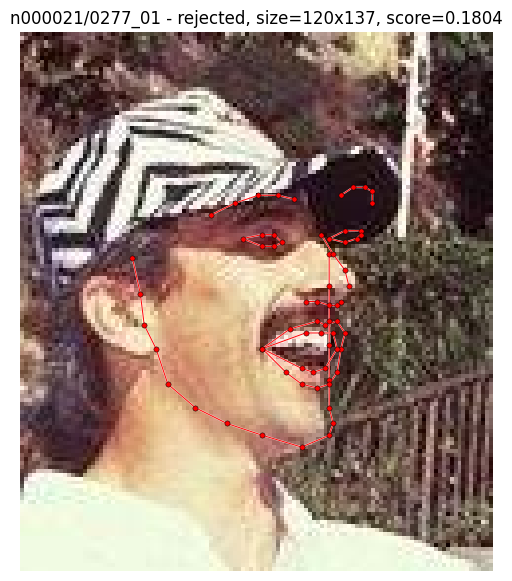

{'name': 'n000021/0277_01',
 'status': 'rejected',
 'score': 0.180430069565773,
 'image_path': PosixPath('/home/jie/Downloads/vggface2_train/train/n000021/0277_01.jpg'),
 'kpt_path': PosixPath('/home/jie/Downloads/vggface2_train/train_annotated_fan/n000021/0277_01.npy'),
 'image_size': (120, 137),
 'landmarks': array([[ 28.,  57.],
        [ 30.,  66.],
        [ 31.,  74.],
        [ 34.,  80.],
        [ 37.,  89.],
        [ 44.,  95.],
        [ 52.,  99.],
        [ 61., 102.],
        [ 71., 105.],
        [ 78., 102.],
        [ 79.,  99.],
        [ 78.,  95.],
        [ 78.,  88.],
        [ 78.,  79.],
        [ 78.,  73.],
        [ 78.,  64.],
        [ 78.,  56.],
        [ 48.,  46.],
        [ 54.,  43.],
        [ 60.,  41.],
        [ 65.,  41.],
        [ 69.,  42.],
        [ 81.,  41.],
        [ 84.,  39.],
        [ 87.,  39.],
        [ 89.,  40.],
        [ 89.,  43.],
        [ 76.,  51.],
        [ 79.,  56.],
        [ 82.,  60.],
        [ 83.,  64.],
      

In [28]:
metadata = np.load(CLEAN_METADATA_PATH, allow_pickle=False)

rejected_names = metadata["rejected_names"].astype(str)
rejected_scores = metadata["rejected_scores"].astype(np.float32)

MIN_SCORE = 0.18
MAX_SCORE = 0.20  # set to None for no upper bound

if MAX_SCORE is None:
    valid = rejected_scores >= MIN_SCORE
else:
    valid = (rejected_scores >= MIN_SCORE) & (rejected_scores <= MAX_SCORE)

filtered_names = rejected_names[valid]
filtered_scores = rejected_scores[valid]

if len(filtered_names) == 0:
    raise RuntimeError(f"No rejected names found with score in range [{MIN_SCORE}, {MAX_SCORE}].")

previous_vis_name = globals().get("VIS_NAME", None)
print("previous name:", previous_vis_name)

rng = np.random.default_rng()
sample_idx = int(rng.integers(len(filtered_names)))

VIS_NAME = str(filtered_names[sample_idx])
score = float(filtered_scores[sample_idx])

print("random rejected name:", VIS_NAME)
print("score range:", MIN_SCORE, "to", MAX_SCORE)
print("score:", score)

show_landmarks_for_name(
    VIS_NAME,
    status="rejected",
    score=score,
    point_color="red",
    draw_lines=True,
    draw_numbers=False,
)


In [90]:
VIS_NAME = NameError

name: n000098/0203_01
image size: 120 x 137
score: 0.1983499825000763
threshold: 0.1
accepted: False
worst landmark: 57
worst normalized distance: 0.1983499825000763


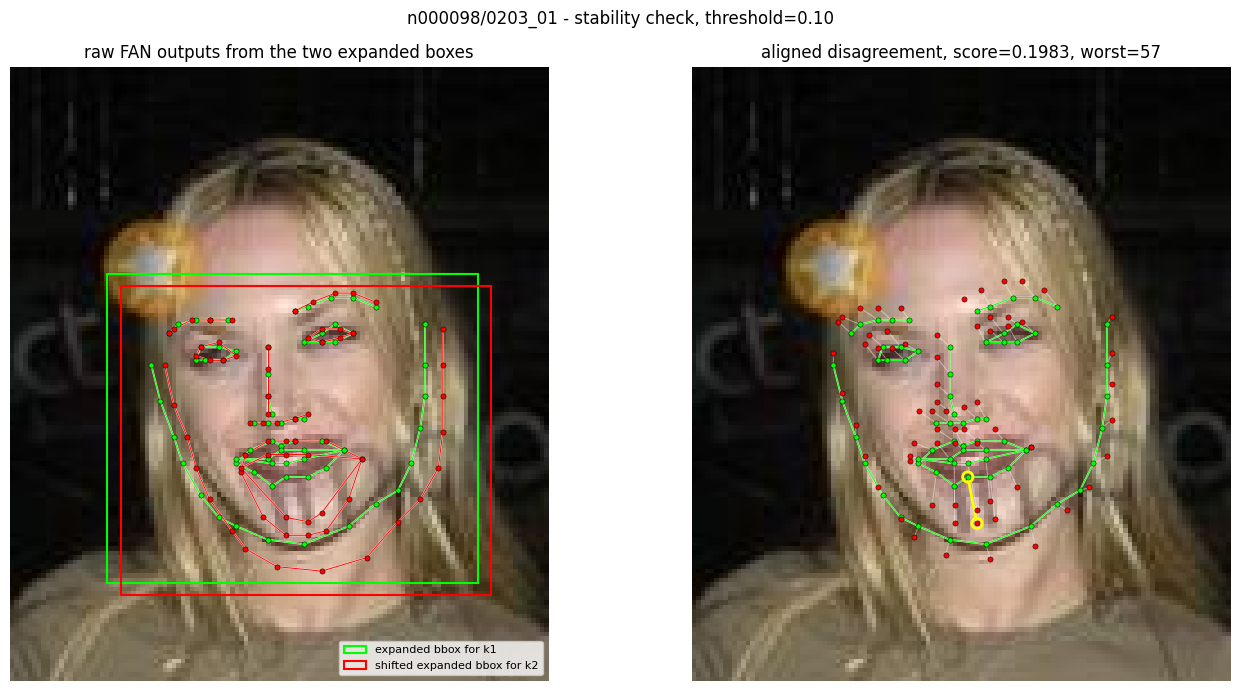

In [142]:
# Visualize the two expanded-bbox FAN passes and the stability score for the current VIS_NAME.
# Run the random rejected cell above first, or set VIS_NAME manually here.
try:
    VIS_NAME
except NameError:
    metadata = np.load(CLEAN_METADATA_PATH, allow_pickle=False)
    rejected_names = metadata['rejected_names'].astype(str)
    if len(rejected_names) == 0:
        raise RuntimeError('No rejected names found.')
    VIS_NAME = str(np.random.default_rng().choice(rejected_names))

image_path = IMAGE_ROOT / f'{VIS_NAME}.jpg'
details = paper_style_stability_details_from_cached_first_pass(
    image_path,
    threshold=STABILITY_THRESHOLD,
)

image = details['image']
k1 = details['k1']
k2 = details['k2']
k2_aligned = details['k2_aligned']
per_landmark_distance = details['per_landmark_distance']
worst_idx = details['worst_landmark_index']
score = details['score']
threshold = details['threshold']
h, w = image.shape[:2]

print('name:', VIS_NAME)
print('image size:', w, 'x', h)
print('score:', score)
print('threshold:', threshold)
print('accepted:', details['accepted'])
print('worst landmark:', worst_idx)
print('worst normalized distance:', float(per_landmark_distance[worst_idx]))

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Left: show the two expanded detection boxes and their raw FAN outputs.
axes[0].imshow(image)
for bbox, color, label in [
    (details['expanded_original_bbox'], 'lime', 'expanded bbox for k1'),
    (details['expanded_shifted_bbox'], 'red', 'shifted expanded bbox for k2'),
]:
    x1, y1, x2, y2 = bbox
    axes[0].add_patch(
        plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            edgecolor=color,
            linewidth=1.5,
            label=label,
        )
    )
plot_68_landmarks(axes[0], k1, point_color='lime', draw_lines=True, draw_numbers=False)
plot_68_landmarks(axes[0], k2, point_color='red', draw_lines=True, draw_numbers=False)
axes[0].set_title('raw FAN outputs from the two expanded boxes')
axes[0].legend(loc='lower right', fontsize=8)
axes[0].axis('off')

# Right: align k2 back by epsilon and draw per-landmark disagreement vectors.
axes[1].imshow(image)
plot_68_landmarks(axes[1], k1, point_color='lime', draw_lines=True, draw_numbers=False)
axes[1].scatter(k2_aligned[:, 0], k2_aligned[:, 1], s=14, c='red', edgecolors='black', linewidths=0.35, zorder=3)

for i in range(k1.shape[0]):
    color = 'yellow' if i == worst_idx else 'white'
    alpha = 1.0 if i == worst_idx else 0.45
    linewidth = 2.0 if i == worst_idx else 0.7
    axes[1].plot(
        [k1[i, 0], k2_aligned[i, 0]],
        [k1[i, 1], k2_aligned[i, 1]],
        color=color,
        alpha=alpha,
        linewidth=linewidth,
    )

axes[1].scatter(k1[worst_idx, 0], k1[worst_idx, 1], s=55, facecolors='none', edgecolors='yellow', linewidths=2.0, zorder=5)
axes[1].scatter(k2_aligned[worst_idx, 0], k2_aligned[worst_idx, 1], s=55, facecolors='none', edgecolors='yellow', linewidths=2.0, zorder=5)
axes[1].set_title(f'aligned disagreement, score={score:.4f}, worst={worst_idx}')
axes[1].axis('off')

plt.suptitle(f'{VIS_NAME} - stability check, threshold={threshold:.2f}', y=0.98)
plt.tight_layout()
plt.show()


In [143]:
# Overview of accepted names text file (.txt)
print('accepted names path:', ACCEPTED_NAMES_PATH)
print('exists:', ACCEPTED_NAMES_PATH.is_file())

if ACCEPTED_NAMES_PATH.is_file():
    accepted_txt_names = [line.strip() for line in ACCEPTED_NAMES_PATH.read_text().splitlines() if line.strip()]
    print('num names in txt:', len(accepted_txt_names))
    print('num unique names in txt:', len(set(accepted_txt_names)))
    print('first 20 names:')
    for name in accepted_txt_names[:20]:
        print(' ', name)

    if CLEAN_LIST_PATH.is_file():
        clean_names = np.load(CLEAN_LIST_PATH, allow_pickle=False).astype(str).reshape(-1).tolist()
        print('matches clean .npy order:', accepted_txt_names == clean_names)
else:
    accepted_txt_names = []


accepted names path: /home/jie/Downloads/vggface2_train/vggface2_train_fan_stability_clean_names.txt
exists: True
num names in txt: 58248
num unique names in txt: 58248
first 20 names:
  n000002/0001_01
  n000002/0002_01
  n000002/0003_01
  n000002/0004_01
  n000002/0005_01
  n000002/0006_01
  n000002/0008_01
  n000002/0009_01
  n000002/0010_01
  n000002/0011_01
  n000002/0012_01
  n000002/0013_01
  n000002/0014_01
  n000002/0015_01
  n000002/0017_01
  n000002/0018_01
  n000002/0018_02
  n000002/0018_04
  n000002/0019_01
  n000002/0020_01
matches clean .npy order: True


In [9]:
clean_names[-1]

np.str_('n001178/0396_02')

image: /home/jie/Downloads/vggface2_train/train/n001178/0396_02.jpg True
landmarks: /home/jie/Downloads/vggface2_train/train_annotated_fan/n001178/0396_02.npy True
image shape: (164, 144, 3)
image size: 144 x 164
landmarks shape: (68, 2)
landmarks min xy: [41. 55.]
landmarks max xy: [106. 121.]
status: accepted
stability score: 0.09230317175388336


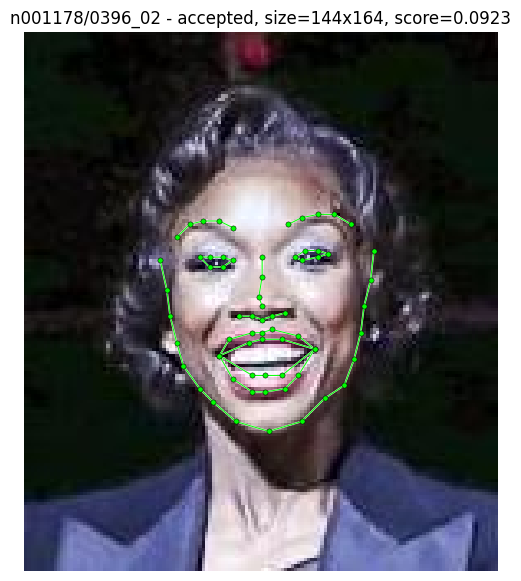

{'name': 'n001178/0396_02',
 'status': 'accepted',
 'score': 0.09230317175388336,
 'image_path': PosixPath('/home/jie/Downloads/vggface2_train/train/n001178/0396_02.jpg'),
 'kpt_path': PosixPath('/home/jie/Downloads/vggface2_train/train_annotated_fan/n001178/0396_02.npy'),
 'image_size': (144, 164),
 'landmarks': array([[ 41.,  69.],
        [ 43.,  78.],
        [ 44.,  86.],
        [ 46.,  94.],
        [ 48., 101.],
        [ 53., 108.],
        [ 57., 112.],
        [ 64., 118.],
        [ 74., 121.],
        [ 84., 118.],
        [ 91., 111.],
        [ 97., 107.],
        [100.,  99.],
        [102.,  91.],
        [103.,  83.],
        [105.,  75.],
        [106.,  66.],
        [ 46.,  62.],
        [ 50.,  58.],
        [ 54.,  57.],
        [ 59.,  57.],
        [ 63.,  59.],
        [ 80.,  58.],
        [ 84.,  56.],
        [ 89.,  55.],
        [ 94.,  55.],
        [ 99.,  58.],
        [ 72.,  68.],
        [ 72.,  74.],
        [ 71.,  80.],
        [ 72.,  83.],
    

In [12]:
# Visualize cached FAN landmarks for one image name.
# Enter a relative image name without extension, e.g. 'n000002/0001_01'.
VIS_NAME = 'n001178/0396_02'
DRAW_LANDMARK_LINES = True
DRAW_LANDMARK_NUMBERS = False

show_landmarks_for_name(
    VIS_NAME,
    point_color='lime',
    draw_lines=DRAW_LANDMARK_LINES,
    draw_numbers=DRAW_LANDMARK_NUMBERS,
)


reading clean image sizes: 100%|██████████| 58248/58248 [00:03<00:00, 17257.89it/s]


clean names: 58248
images found: 58248
missing: 0
unique sizes: 22613
width min/median/mean/max: 45 232.0 262.3134528224145 2492
height min/median/mean/max: 48 253.0 278.4670889987639 2820
square size percentiles 1/5/25/50/75/95/99: [ 80.   111.   174.   256.   363.   581.   782.53]
square size counts by percentile bucket:
  <= p1: 614 images (1.05%)
  p1-p5: 2304 images (3.96%)
  p5-p25: 11766 images (20.20%)
  p25-p50: 14568 images (25.01%)
  p50-p75: 14441 images (24.79%)
  p75-p95: 11661 images (20.02%)
  p95-p99: 2311 images (3.97%)
  > p99: 583 images (1.00%)


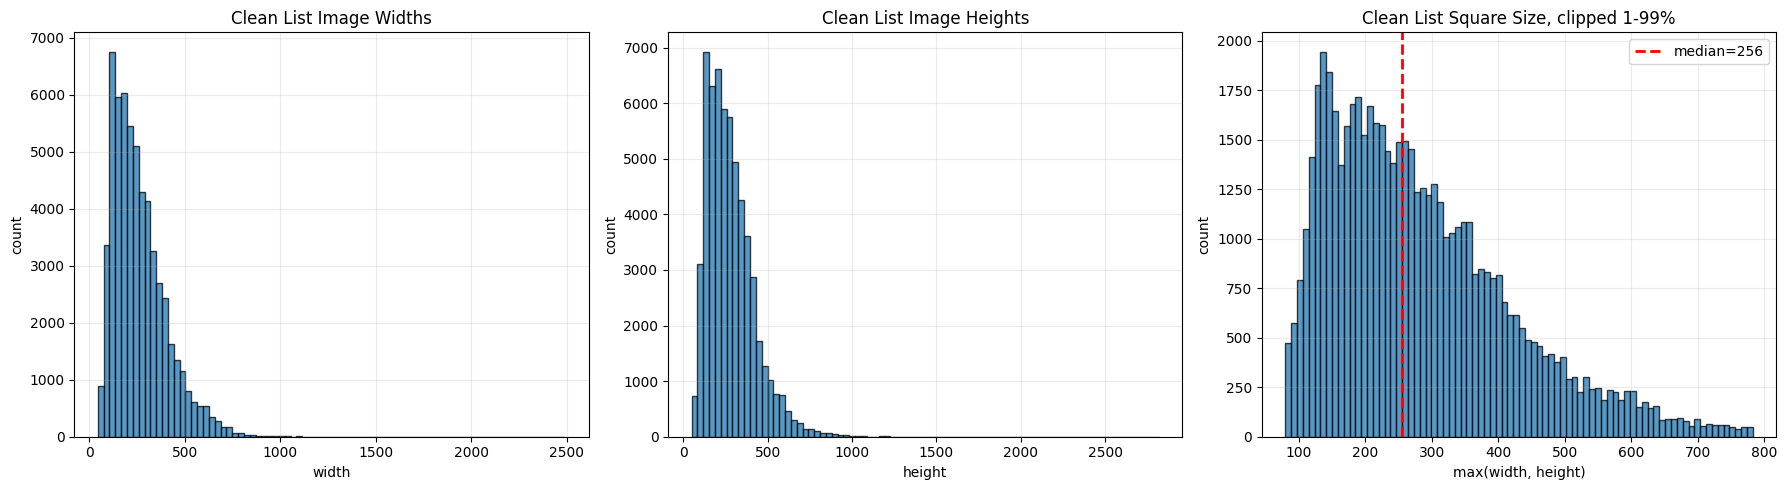

In [145]:
# Histogram of original image sizes for accepted names in the clean list.
from PIL import Image

if not CLEAN_LIST_PATH.is_file():
    raise FileNotFoundError(CLEAN_LIST_PATH)

clean_names = np.load(CLEAN_LIST_PATH, allow_pickle=False).astype(str).reshape(-1)
if len(clean_names) == 0:
    raise RuntimeError('Clean list is empty.')

sizes = []
missing = []
for name in tqdm(clean_names, desc='reading clean image sizes'):
    image_path = IMAGE_ROOT / f'{name}.jpg'
    if not image_path.is_file():
        missing.append(name)
        continue
    with Image.open(image_path) as img:
        w, h = img.size
    sizes.append((w, h))

sizes = np.asarray(sizes, dtype=np.int32)
widths = sizes[:, 0]
heights = sizes[:, 1]
square_sizes = np.maximum(widths, heights)

print('clean names:', len(clean_names))
print('images found:', len(sizes))
print('missing:', len(missing))
print('unique sizes:', len(set(map(tuple, sizes))))
print('width min/median/mean/max:', int(widths.min()), float(np.median(widths)), float(widths.mean()), int(widths.max()))
print('height min/median/mean/max:', int(heights.min()), float(np.median(heights)), float(heights.mean()), int(heights.max()))
percentile_marks = [1, 5, 25, 50, 75, 95, 99]
percentile_values = np.percentile(square_sizes, percentile_marks)
print('square size percentiles 1/5/25/50/75/95/99:', percentile_values)

print('square size counts by percentile bucket:')
bucket_edges = [-np.inf] + percentile_values.tolist() + [np.inf]
bucket_labels = ['<= p1', 'p1-p5', 'p5-p25', 'p25-p50', 'p50-p75', 'p75-p95', 'p95-p99', '> p99']
for label, left, right in zip(bucket_labels, bucket_edges[:-1], bucket_edges[1:]):
    if np.isneginf(left):
        mask = square_sizes <= right
    elif np.isposinf(right):
        mask = square_sizes > left
    else:
        mask = (square_sizes > left) & (square_sizes <= right)
    count = int(np.count_nonzero(mask))
    pct = 100.0 * count / len(square_sizes)
    print(f'  {label}: {count} images ({pct:.2f}%)')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(widths, bins=80, edgecolor='black', alpha=0.75)
axes[0].set_title('Clean List Image Widths')
axes[0].set_xlabel('width')
axes[0].set_ylabel('count')
axes[0].grid(alpha=0.25)

axes[1].hist(heights, bins=80, edgecolor='black', alpha=0.75)
axes[1].set_title('Clean List Image Heights')
axes[1].set_xlabel('height')
axes[1].set_ylabel('count')
axes[1].grid(alpha=0.25)

lo, hi = np.percentile(square_sizes, [1, 99])
axes[2].hist(square_sizes, bins=80, range=(lo, hi), edgecolor='black', alpha=0.75)
axes[2].axvline(np.median(square_sizes), color='red', linestyle='--', linewidth=2, label=f'median={np.median(square_sizes):.0f}')
axes[2].set_title('Clean List Square Size, clipped 1-99%')
axes[2].set_xlabel('max(width, height)')
axes[2].set_ylabel('count')
axes[2].legend()
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()
